# Expectation Decider
### Probability Analysis of Student Exam Results

**Goal:** Use data of 200 students to understand the chance (probability) of passing a competitive mathematics exam.

**Dataset columns**

| Column | Meaning |
|---|---|
| study_hours | Hours studied per week |
| attendance | Attendance in lectures (%) |
| group_discussion | Took part in group discussion (Yes / No) |
| previous_test_score | Marks out of 100 in the last internal test |
| final_exam_pass | Result of competitive exam (Pass / Fail) |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from scipy import stats
import os

os.makedirs("figures", exist_ok=True)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("student_data.csv")
N = len(df)
print("Number of students:", N)
df.head()

Number of students: 200


,student_id,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,S001,12.2,83,Yes,55,Pass
1,S002,6.8,93,No,57,Fail
2,S003,14.0,80,Yes,71,Pass
3,S004,14.8,87,Yes,56,Fail
4,S005,3.2,50,No,46,Fail


In [2]:
print(df.info())
print()
df.describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           200 non-null    str    
 1   study_hours          200 non-null    float64
 2   attendance           200 non-null    int64  
 3   group_discussion     200 non-null    str    
 4   previous_test_score  200 non-null    int64  
 5   final_exam_pass      200 non-null    str    
dtypes: float64(1), int64(2), str(3)
memory usage: 9.5 KB
None



,study_hours,attendance,previous_test_score
count,200.00,200.00,200.00
mean,10.88,77.96,53.90
std,3.53,11.77,15.89
min,2.50,47.00,15.00
25%,8.40,70.00,43.00
50%,10.80,78.00,53.50
75%,13.12,86.00,63.00
max,22.70,100.00,93.00


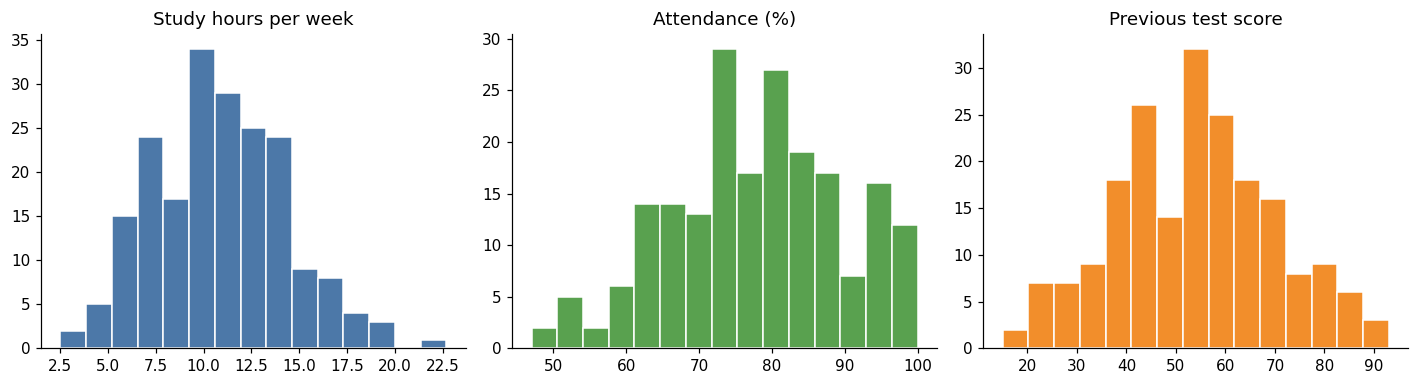

In [3]:
# Quick look at the data
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
ax[0].hist(df["study_hours"], bins=15, color="#4C78A8", edgecolor="white")
ax[0].set_title("Study hours per week")
ax[1].hist(df["attendance"], bins=15, color="#59A14F", edgecolor="white")
ax[1].set_title("Attendance (%)")
ax[2].hist(df["previous_test_score"], bins=15, color="#F28E2B", edgecolor="white")
ax[2].set_title("Previous test score")
plt.tight_layout()
plt.savefig("figures/01_distributions.png", bbox_inches="tight")
plt.show()

---
## Task 1: Understanding the Basics

### What is Probability?
Probability tells us **how likely** it is that something will happen. It is a number from **0 to 1**.
- 0 means the event can never happen.
- 1 means the event will surely happen.
- 0.5 means it is equally likely to happen or not.

$$P(E) = \frac{\text{Number of favourable outcomes}}{\text{Total number of outcomes}}$$

### Key Probability Terms

| Term | Simple meaning | Example here |
|---|---|---|
| Experiment | An action whose result is not fixed | Picking one student at random |
| Outcome | One possible result of the experiment | The chosen student passed |
| Sample space (S) | The set of all possible outcomes | All 200 students |
| Event (E) | A group of outcomes we care about | Students who passed |
| Complement (E') | Event "E does not happen" | Students who failed |
| Mutually exclusive events | Two events that cannot happen together | Pass and Fail |
| Independent events | One event does not change the chance of the other | (tested later) |
| Joint probability | Chance that A and B both happen, P(A ∩ B) | Group discussion AND pass |
| Marginal probability | Chance of one event alone | P(Pass) |
| Conditional probability | Chance of A when B is already known, P(A \| B) | P(Pass \| group discussion) |

### Three Probability Event Examples from the Dataset

In [4]:
# Event 1: a student passes the exam
p_pass = (df["final_exam_pass"] == "Pass").sum() / N

# Event 2: a student studies more than 10 hours per week
p_study = (df["study_hours"] > 10).sum() / N

# Event 3: a student has attendance above 80%
p_att = (df["attendance"] > 80).sum() / N

events = pd.DataFrame({
    "Event": ["Student passes the exam", "Study hours > 10", "Attendance > 80%"],
    "Favourable students": [(df["final_exam_pass"] == "Pass").sum(), (df["study_hours"] > 10).sum(), (df["attendance"] > 80).sum()],
    "Total students": [N, N, N],
    "Probability": [p_pass, p_study, p_att],
})
events["Probability"] = events["Probability"].round(4)
events

,Event,Favourable students,Total students,Probability
0,Student passes the exam,91,200,0.455
1,Study hours > 10,115,200,0.575
2,Attendance > 80%,82,200,0.410


**Meaning:** about 45.5% of students passed, 57.5% studied more than 10 hours, and 41% had attendance above 80%.

---
## Task 2: Types of Events (Empirical and Theoretical)

- **Empirical probability** is found from **real observed data**: `P = (times event happened) / (total trials)`.
- **Theoretical probability** is found from **logic**, assuming all outcomes are equally likely: `P = favourable outcomes / total possible outcomes`.

**Empirical scenario:** a random student passes the exam. We count the real results in the data.

**Theoretical scenario:** a random student takes part in group discussion. There are 2 possible outcomes (Yes, No). If both are equally likely, then theoretically `P(Yes) = 1/2`.
Then we compare it with what the data really shows.

In [5]:
# Empirical probability of passing
passed = (df["final_exam_pass"] == "Pass").sum()
empirical_pass = passed / N
print(f"EMPIRICAL  P(Pass) = {passed}/{N} = {empirical_pass:.4f}")

# Theoretical probability of group discussion = Yes (2 equally likely outcomes)
theoretical_gd = 1 / 2
print(f"THEORETICAL P(GD = Yes) = 1/2 = {theoretical_gd:.4f}")

# Compare with the real data
gd_yes = (df["group_discussion"] == "Yes").sum()
empirical_gd = gd_yes / N
print(f"Observed    P(GD = Yes) = {gd_yes}/{N} = {empirical_gd:.4f}")
print(f"Difference (observed - theoretical) = {empirical_gd - theoretical_gd:+.4f}")

EMPIRICAL  P(Pass) = 91/200 = 0.4550
THEORETICAL P(GD = Yes) = 1/2 = 0.5000
Observed    P(GD = Yes) = 104/200 = 0.5200
Difference (observed - theoretical) = +0.0200


**Meaning:** The theoretical value is 0.50 and the real data gives 0.52. They are close, so the "equal chance" idea is a good guess here. The empirical value is the one we trust for passing, because the chance of passing is not 50-50 by logic. We can only learn it from data.

---
## Task 3: Random Variable and Probability Distribution

### Random variable
A **random variable** gives a number to the result of a random experiment.

**Let X = number of students who pass the final exam out of 3 randomly selected students.**
X can take values 0, 1, 2 or 3.

Each student passes with probability `p = P(Pass)` (from the data) and fails with `q = 1 - p`.
We treat the 3 students as independent trials, so X follows a **Binomial distribution** with `n = 3`.

$$P(X = x) = \binom{3}{x} p^{x} q^{3-x}$$

In [6]:
from math import comb

n = 3
p = empirical_pass
q = 1 - p
print(f"p = {p:.4f}, q = {q:.4f}\n")

rows = []
for x in range(n + 1):
    px = comb(n, x) * (p ** x) * (q ** (n - x))
    rows.append([x, f"C(3,{x}) x {p:.3f}^{x} x {q:.3f}^{n-x}", px])

dist = pd.DataFrame(rows, columns=["x", "Working", "P(X = x)"])
dist["x * P(x)"] = dist["x"] * dist["P(X = x)"]
dist["x^2 * P(x)"] = dist["x"] ** 2 * dist["P(X = x)"]
display(dist.round(4))
print("Sum of probabilities =", round(dist["P(X = x)"].sum(), 4))

p = 0.4550, q = 0.5450



,x,Working,P(X = x),x * P(x),x^2 * P(x)
0,0,"C(3,0) x 0.455^0 x 0.545^3",0.1619,0.0000,0.0000
1,1,"C(3,1) x 0.455^1 x 0.545^2",0.4054,0.4054,0.4054
2,2,"C(3,2) x 0.455^2 x 0.545^1",0.3385,0.6770,1.3539
3,3,"C(3,3) x 0.455^3 x 0.545^0",0.0942,0.2826,0.8478


Sum of probabilities = 1.0


In [7]:
# Mean and variance from the table
mean_x = dist["x * P(x)"].sum()
ex2 = dist["x^2 * P(x)"].sum()
var_x = ex2 - mean_x ** 2

print(f"Mean     E(X)   = sum of x*P(x)       = {mean_x:.4f}")
print(f"E(X^2)          = sum of x^2*P(x)     = {ex2:.4f}")
print(f"Variance Var(X) = E(X^2) - [E(X)]^2   = {var_x:.4f}")
print(f"Std. deviation                        = {np.sqrt(var_x):.4f}")

# Check with the binomial shortcut formulas
print()
print(f"Check: n*p     = {n*p:.4f}")
print(f"Check: n*p*q   = {n*p*q:.4f}")

Mean     E(X)   = sum of x*P(x)       = 1.3650
E(X^2)          = sum of x^2*P(x)     = 2.6071
Variance Var(X) = E(X^2) - [E(X)]^2   = 0.7439
Std. deviation                        = 0.8625

Check: n*p     = 1.3650
Check: n*p*q   = 0.7439


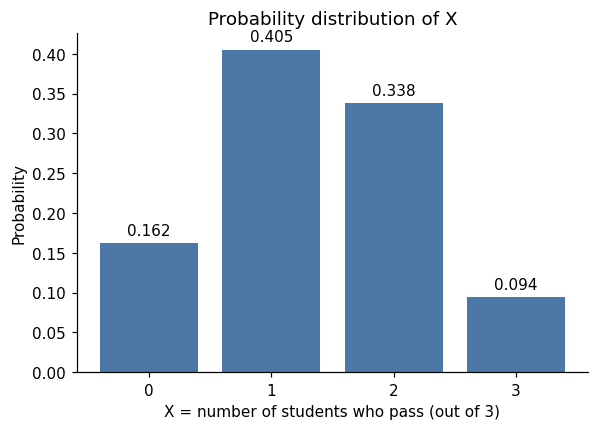

In [8]:
plt.figure(figsize=(6, 4))
bars = plt.bar(dist["x"], dist["P(X = x)"], color="#4C78A8")
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{b.get_height():.3f}", ha="center")
plt.xticks([0, 1, 2, 3])
plt.xlabel("X = number of students who pass (out of 3)")
plt.ylabel("Probability")
plt.title("Probability distribution of X")
plt.savefig("figures/02_distribution_X.png", bbox_inches="tight")
plt.show()

**Meaning:** If we pick 3 students at random, we expect about **1.37 students** (mean = 1.365) to pass. The most likely result is exactly 1 pass.

---
## Task 4: Venn Diagram

- **Set A:** students who study more than 10 hours per week
- **Set B:** students who attend more than 80% of classes
- **A ∩ B (overlap):** students who satisfy both

In [9]:
A = df["study_hours"] > 10
B = df["attendance"] > 80

only_A = (A & ~B).sum()
only_B = (B & ~A).sum()
both = (A & B).sum()
neither = (~A & ~B).sum()

print("Only study > 10 hours      :", only_A)
print("Only attendance > 80%      :", only_B)
print("Both conditions (overlap)  :", both)
print("Neither condition          :", neither)
print("Total                      :", only_A + only_B + both + neither)

Only study > 10 hours      : 65
Only attendance > 80%      : 32
Both conditions (overlap)  : 50
Neither condition          : 53
Total                      : 200


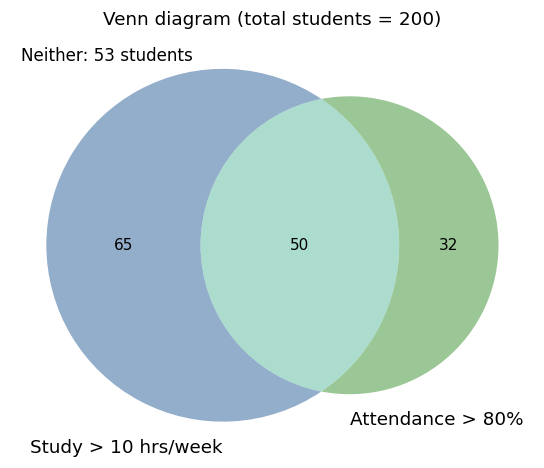

P(A)       = 115/200 = 0.575
P(B)       = 82/200 = 0.410
P(A and B) = 50/200 = 0.250
P(A or B)  = 147/200 = 0.735
Addition rule check: P(A) + P(B) - P(A and B) = 0.735


In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
v = venn2(subsets=(only_A, only_B, both),
          set_labels=("Study > 10 hrs/week", "Attendance > 80%"),
          set_colors=("#4C78A8", "#59A14F"), alpha=0.6, ax=ax)
ax.text(0.02, 0.97, f"Neither: {neither} students", fontsize=11, transform=ax.transAxes, va="top")
ax.set_title(f"Venn diagram (total students = {N})")
plt.savefig("figures/03_venn.png", bbox_inches="tight")
plt.show()

print(f"P(A)       = {A.sum()}/{N} = {A.mean():.3f}")
print(f"P(B)       = {B.sum()}/{N} = {B.mean():.3f}")
print(f"P(A and B) = {both}/{N} = {both/N:.3f}")
print(f"P(A or B)  = {(A|B).sum()}/{N} = {(A|B).mean():.3f}")
print("Addition rule check: P(A) + P(B) - P(A and B) =", round(A.mean() + B.mean() - both/N, 3))

**Meaning:** 50 students (25%) are strong in both study hours and attendance. 53 students (26.5%) are in neither group.

---
## Task 5: Contingency Table and Probability Calculations

In [11]:
table = pd.crosstab(df["group_discussion"], df["final_exam_pass"], margins=True, margins_name="Total")
table = table[["Pass", "Fail", "Total"]]
table

final_exam_pass,Pass,Fail,Total
group_discussion,,,
No,31,65,96
Yes,60,44,104
Total,91,109,200


In [12]:
n_yes_pass = table.loc["Yes", "Pass"]
n_pass = table.loc["Total", "Pass"]
n_yes = table.loc["Yes", "Total"]
grand = table.loc["Total", "Total"]

# Joint probability
p_joint = n_yes_pass / grand
print(f"JOINT       P(GD=Yes AND Pass) = {n_yes_pass}/{grand} = {p_joint:.4f}")

# Marginal probability
p_marg = n_pass / grand
print(f"MARGINAL    P(Pass)            = {n_pass}/{grand} = {p_marg:.4f}")

# Conditional probability
p_cond = n_yes_pass / n_yes
print(f"CONDITIONAL P(Pass | GD=Yes)   = {n_yes_pass}/{n_yes} = {p_cond:.4f}")

# Same result using the formula P(A|B) = P(A and B) / P(B)
p_gd = n_yes / grand
print(f"Formula check: P(Pass and GD) / P(GD) = {p_joint:.4f} / {p_gd:.4f} = {p_joint/p_gd:.4f}")

JOINT       P(GD=Yes AND Pass) = 60/200 = 0.3000
MARGINAL    P(Pass)            = 91/200 = 0.4550
CONDITIONAL P(Pass | GD=Yes)   = 60/104 = 0.5769
Formula check: P(Pass and GD) / P(GD) = 0.3000 / 0.5200 = 0.5769


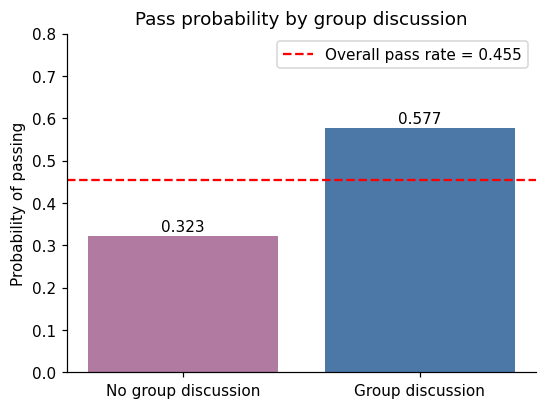

In [13]:
# Chart: pass rate for each group
rate = pd.crosstab(df["group_discussion"], df["final_exam_pass"], normalize="index")["Pass"]
plt.figure(figsize=(5.5, 4))
bars = plt.bar(["No group discussion", "Group discussion"], [rate["No"], rate["Yes"]], color=["#B07AA1", "#4C78A8"])
plt.axhline(p_marg, color="red", linestyle="--", label=f"Overall pass rate = {p_marg:.3f}")
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{b.get_height():.3f}", ha="center")
plt.ylim(0, 0.8)
plt.ylabel("Probability of passing")
plt.title("Pass probability by group discussion")
plt.legend()
plt.savefig("figures/04_pass_by_gd.png", bbox_inches="tight")
plt.show()

---
## Task 6: Understanding Relationships

### Intuition behind conditional probability
Conditional probability means **"change the sample space"**. When we are told a student took part in group discussion, we stop looking at all 200 students. We look only at the 104 students who took part, and ask: out of these, how many passed?

`P(Pass | GD = Yes) = 60 / 104 = 0.577`

So a student who joins group discussions has about a **57.7% chance** of passing, which is higher than the overall chance of **45.5%**. Knowing about group discussion has given us useful extra information.

### Are the events independent, dependent or mutually exclusive?
- **Independent:** `P(A and B) = P(A) x P(B)`, or `P(A | B) = P(A)`.
- **Mutually exclusive:** `P(A and B) = 0`.

In [14]:
p_A = p_gd          # P(GD = Yes)
p_B = p_marg        # P(Pass)

print(f"P(GD) x P(Pass)    = {p_A:.4f} x {p_B:.4f} = {p_A * p_B:.4f}")
print(f"P(GD and Pass)     = {p_joint:.4f}")
print(f"P(Pass | GD)       = {p_cond:.4f}   vs   P(Pass) = {p_B:.4f}")
print()
print("Mutually exclusive?  P(GD and Pass) =", round(p_joint, 4), "which is not 0  ->  NOT mutually exclusive")
print("Independent?         P(GD and Pass) != P(GD) x P(Pass)  ->  NOT independent")

# Chi-square test of independence (extra check)
chi2, p_value, dof, expected = stats.chi2_contingency(pd.crosstab(df["group_discussion"], df["final_exam_pass"]))
print(f"\nChi-square = {chi2:.3f}, degrees of freedom = {dof}, p-value = {p_value:.5f}")
print("Result:", "Dependent (p < 0.05)" if p_value < 0.05 else "No strong proof of dependence (p >= 0.05)")

P(GD) x P(Pass)    = 0.5200 x 0.4550 = 0.2366
P(GD and Pass)     = 0.3000
P(Pass | GD)       = 0.5769   vs   P(Pass) = 0.4550

Mutually exclusive?  P(GD and Pass) = 0.3 which is not 0  ->  NOT mutually exclusive
Independent?         P(GD and Pass) != P(GD) x P(Pass)  ->  NOT independent

Chi-square = 11.984, degrees of freedom = 1, p-value = 0.00054
Result: Dependent (p < 0.05)


**Conclusion:** "Participating in group discussion" and "Passing the exam" are **dependent** events. They are **not mutually exclusive** because many students did both.
The chi-square test (p-value below 0.05) also supports this result.

*Important:* dependent does not mean "cause". It only means the two are linked in this data.

---
## Task 7: Bayes Theorem

**Given**
- P(High attendance | Pass) = 0.70
- P(High attendance | Fail) = 0.40
- P(High attendance) = 0.60

**Find:** P(Pass | High attendance)

$$P(\text{Pass} \mid H) = \frac{P(H \mid \text{Pass}) \times P(\text{Pass})}{P(H)}$$

We are not given P(Pass) directly. But we can get it from the **law of total probability**:

$$P(H) = P(H \mid \text{Pass})P(\text{Pass}) + P(H \mid \text{Fail})\,[1 - P(\text{Pass})]$$

$$0.60 = 0.70\,x + 0.40\,(1 - x) \;\Rightarrow\; 0.60 = 0.40 + 0.30\,x \;\Rightarrow\; x = \frac{0.20}{0.30} = 0.6667$$

In [15]:
p_H_given_pass = 0.70
p_H_given_fail = 0.40
p_H = 0.60

# Step 1: find P(Pass) using total probability
p_pass_hist = (p_H - p_H_given_fail) / (p_H_given_pass - p_H_given_fail)
print(f"Step 1: P(Pass) = (0.60 - 0.40) / (0.70 - 0.40) = {p_pass_hist:.4f}")

# Step 2: Bayes theorem
p_pass_given_H = p_H_given_pass * p_pass_hist / p_H
print(f"Step 2: P(Pass | H) = (0.70 x {p_pass_hist:.4f}) / 0.60 = {p_pass_given_H:.4f}")
print(f"Answer: about {p_pass_given_H*100:.1f}%")

# Check: P(Fail | H)
p_fail_given_H = p_H_given_fail * (1 - p_pass_hist) / p_H
print(f"Check: P(Fail | H) = {p_fail_given_H:.4f}   and   sum = {p_pass_given_H + p_fail_given_H:.4f}")

Step 1: P(Pass) = (0.60 - 0.40) / (0.70 - 0.40) = 0.6667
Step 2: P(Pass | H) = (0.70 x 0.6667) / 0.60 = 0.7778
Answer: about 77.8%
Check: P(Fail | H) = 0.2222   and   sum = 1.0000


**Meaning:** A student with high attendance has about a **77.8% chance** of passing in this historical data.

*Note:* The historical numbers in the question imply that 66.7% of students passed. Our sample of 200 students has a pass rate of 45.5%, so the two are different groups of students. That is fine because the question says to *suppose* this historical data.

---
## Final Summary: What Affects the Chance of Passing?

We compare students who passed with students who failed, and check the pass rate inside groups.

,study_hours,attendance,previous_test_score
final_exam_pass,,,
Fail,10.18,75.79,49.16
Pass,11.72,80.56,59.58


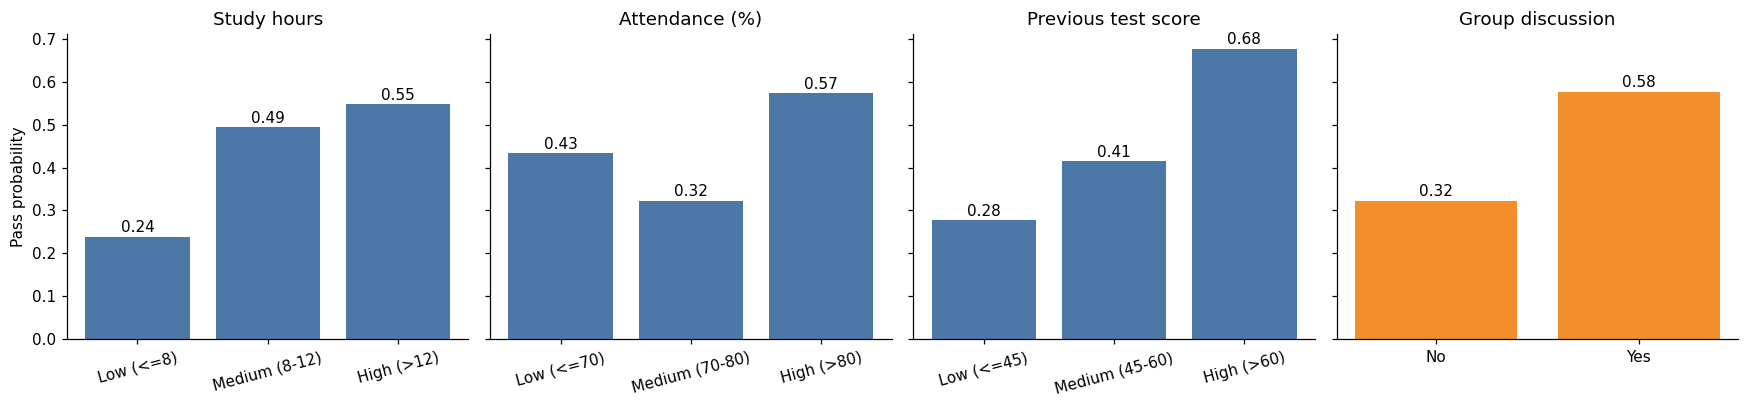

In [16]:
summary = df.groupby("final_exam_pass")[["study_hours", "attendance", "previous_test_score"]].mean().round(2)
display(summary)

# Pass rate by band
df["study_band"] = pd.cut(df["study_hours"], [0, 8, 12, 30], labels=["Low (<=8)", "Medium (8-12)", "High (>12)"])
df["attendance_band"] = pd.cut(df["attendance"], [0, 70, 80, 100], labels=["Low (<=70)", "Medium (70-80)", "High (>80)"])
df["score_band"] = pd.cut(df["previous_test_score"], [0, 45, 60, 100], labels=["Low (<=45)", "Medium (45-60)", "High (>60)"])
df["passed"] = (df["final_exam_pass"] == "Pass").astype(int)

fig, ax = plt.subplots(1, 4, figsize=(16, 3.8), sharey=True)
for a, (col, title) in zip(ax[:3], [("study_band", "Study hours"), ("attendance_band", "Attendance (%)"), ("score_band", "Previous test score")]):
    r = df.groupby(col, observed=True)["passed"].mean()
    a.bar(r.index.astype(str), r.values, color="#4C78A8")
    for i, v in enumerate(r.values):
        a.text(i, v + 0.01, f"{v:.2f}", ha="center")
    a.set_title(title)
    a.tick_params(axis="x", rotation=15)
r = df.groupby("group_discussion")["passed"].mean()
ax[3].bar(r.index, r.values, color="#F28E2B")
for i, v in enumerate(r.values):
    ax[3].text(i, v + 0.01, f"{v:.2f}", ha="center")
ax[3].set_title("Group discussion")
ax[0].set_ylabel("Pass probability")
plt.tight_layout()
plt.savefig("figures/05_pass_rate_by_factor.png", bbox_inches="tight")
plt.show()

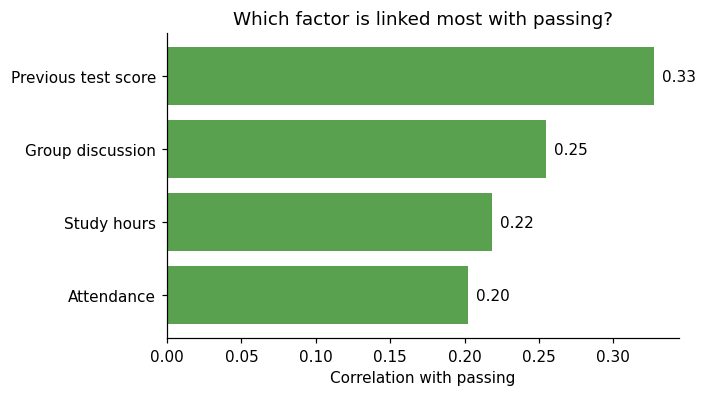

Previous test score    0.327
Group discussion       0.255
Study hours            0.219
Attendance             0.202
Name: passed, dtype: float64

In [17]:
# Strength of link with passing (point-biserial correlation)
df["gd_num"] = (df["group_discussion"] == "Yes").astype(int)
corr = df[["study_hours", "attendance", "previous_test_score", "gd_num", "passed"]].corr()["passed"].drop("passed")
corr = corr.rename({"study_hours": "Study hours", "attendance": "Attendance", "previous_test_score": "Previous test score", "gd_num": "Group discussion"}).sort_values()

plt.figure(figsize=(6, 3.6))
plt.barh(corr.index, corr.values, color="#59A14F")
for i, v in enumerate(corr.values):
    plt.text(v + 0.005, i, f"{v:.2f}", va="center")
plt.xlabel("Correlation with passing")
plt.title("Which factor is linked most with passing?")
plt.savefig("figures/06_correlation.png", bbox_inches="tight")
plt.show()
corr.round(3).sort_values(ascending=False)

### Final Conclusions
1. **Overall chance of passing** is about **45.5%** (91 of 200 students).
2. **Previous test score** and **group discussion** show the strongest link with passing. Students with higher past scores and those who join group discussions pass more often.
3. **Study hours** and **attendance** also matter, but their links are weaker (correlation about 0.22 and 0.20). Students above 80% attendance pass more often, and Bayes theorem gives a 77.8% chance of passing for high attendance in the historical case.
4. In this data the order of importance is: previous test score, then group discussion, then study hours, then attendance.
5. Group discussion and passing are **dependent** events, but this does not prove that one *causes* the other.